                        Cognifyz: Internship Program in the field of Data Science

        LEVEL2 TASK1:  Table Booking and Online Delivery   

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set(color_codes=True)
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore")

file_path = r"E:\COLLEGGE\6 SEMESTER\Internship cognifyz\Dataset .csv"


try:
     dataset = pd.read_csv(file_path, sep=",", on_bad_lines='skip', encoding="utf-8-sig")
     print("FILE READ SUCESSFULLY")
except FileNotFoundError:
     print(f"File not found: {file_path}")

FILE READ SUCESSFULLY


In [4]:
dataset.head(1)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

 Determine the percentage of restaurants that
 offer table booking and online delivery.

In [7]:
##determine the no number of restaurants that offer table booking and online delivery
dataset["Has Online delivery"].value_counts()

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

In [8]:
dataset["Has Table booking"].value_counts()

Has Table booking
No     8393
Yes    1158
Name: count, dtype: int64

In [9]:
#percentage determination 
tpercentage=round(1158/(8393+1158),2)*100
print("Table booking has a",tpercentage,"%")
delivery_p=round(2451/(2451+7100),2)*100
print("Online delivery has a ",delivery_p,"%")

Table booking has a 12.0 %
Online delivery has a  26.0 %


In [12]:
#table_booking=dataset["Has Table Booking"].value_counts.get("Yes")
#Online_del_booking=dataset["Has Online Delivery"].value_counts.get("Yes")
online_delivery = dataset[dataset['Has Online delivery'] == 'Yes']
perc_online_delivery = (online_delivery['Has Online delivery'].count() / dataset['Has Online delivery'].count()) * 100
print("Percentage of Restaurants offers online delivery : {:.2f} %".format(perc_online_delivery))

data_with_table_booking = dataset[dataset['Has Table booking'] == 'Yes']
perc_with_table_booking = (data_with_table_booking['Has Table booking'].count() / dataset['Has Table booking'].count()) * 100
print("Percentage of Restaurants has table booking : {:.2f} %".format(perc_with_table_booking))

Percentage of Restaurants offers online delivery : 25.66 %
Percentage of Restaurants has table booking : 12.12 %


 Compare the average ratings of restaurants
 with table booking and those without.

In [14]:
#Copute the average rating of restuarants that with table booking and thiose without
With_table_booking = dataset[dataset['Has Table booking'] == 'Yes']
Without_table_booking = dataset[dataset['Has Table booking'] == 'No']

print("Rows With Table : ", With_table_booking.shape)
print("Rows Without Table : ", Without_table_booking.shape)

print("Average Ratings of Restaurants with or without table booking:")
print("  With Table Booking : ", round(With_table_booking["Aggregate rating"].mean(), 2))
print(" Without Table Booking : ", round(Without_table_booking["Aggregate rating"].mean(), 2))


Rows With Table :  (1158, 21)
Rows Without Table :  (8393, 21)
Average Ratings of Restaurants with or without table booking:
  With Table Booking :  3.44
 Without Table Booking :  2.56


 Analyze the availability of online delivery
 among restaurants with different price ranges.

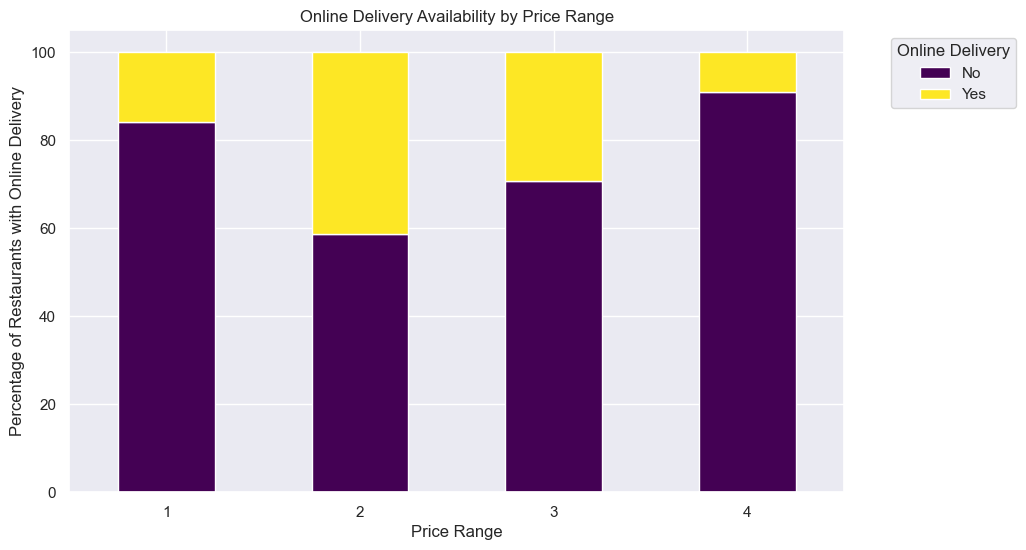

In [15]:
#ANALYZE THE AVAILABILITY OF ONLINE DELIVERY AMONG RESTAURANTS WITH DIFFERENT PTRICE RANGES  
Online_Delivery_by_price_range = dataset.groupby("Price range")["Has Online delivery"].value_counts(normalize=True).unstack() * 100
Online_Delivery_by_price_range.plot(kind="bar", stacked=True, colormap="viridis", figsize=(10, 6))
plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants with Online Delivery")
plt.xticks(rotation=0)
plt.legend(title="Online Delivery", bbox_to_anchor=(1.05, 1))
plt.show()




<Figure size 1000x600 with 0 Axes>

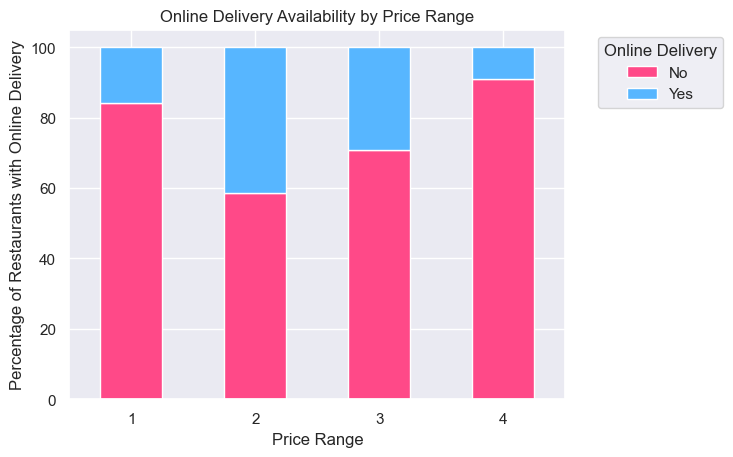

In [16]:

# Group data by "Price range" and calculate the percentage of restaurants with online delivery
Online_Delivery_by_price_range = dataset.groupby("Price range")["Has Online delivery"].value_counts(normalize=True).unstack() * 100

# Create a stacked bar plot with customizations
plt.figure(figsize=(10, 6))
colors = ["#FF4988", "#57B6FF"]  # Custom colors for "Yes" and "No" bars
Online_Delivery_by_price_range.plot(kind="bar", stacked=True, color=colors)  # Corrected 'colormap' to 'color'
plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants with Online Delivery")
plt.xticks(rotation=0)
plt.legend(title="Online Delivery", bbox_to_anchor=(1.05, 1))
plt.show()
